In [ ]:
from IPython.display import display, HTML
display(HTML("""
<style>
div.container{width:98% !important;}
div.cell.code_cell.rendered{width:100%;}
div.input_prompt{padding:0px;}
div.CodeMirror {font-family:Consolas; font-size:20pt;}
div.text_cell_render.rendered_html{font-size:18pt;}
div.text_cell_render.rendered_html{font-size:15pt;}
div.output {font-size:18pt; font-weight:bold;}
div.input {font-family:Consolas; font-size:18pt;}
div.prompt {min-width:70px;}
div#toc-wrapper{padding-top:120px;}
div.text_cell_render ul li{font-size:18pt;padding:5px;}
table.dataframe{font-size:18px;}
</style>
"""))

<b><font color="red" size="6">심장병예제(로지스틱회귀분석=이진분류,분류분석)</font></b>

# 이진분류
```
1. 데이터 셋 생성 & 전처리
      엑셀 -> 데이터프레임 -> ? 처리(df.replace('?',np.nan) -> 결측치 처리
      -> X, y 분리 -> X변수 스케일 조정 -> train_test_split함수로 학습셋과 테스트셋 분리
2. 모델 생성(입력13, 출력1) & 학습과정 설정 & 학습
3. 모델 평가(그래프, 평가, 교차표)
4. 모델 사용(저장, 예측)
```

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import sys # 최대한 출력을 많이해라 그런거 할지 몰라서 넣었음
from tensorflow.keras.utils import to_categorical # utils.to_categorical 원핫인코딩
from tensorflow.keras import utils
from tensorflow.keras.models import Sequential, save_model, load_model # 모델 생성
from tensorflow.keras.layers import Input, Dense, Dropout # 계산층
from sklearn.metrics import confusion_matrix # 혼동행렬
from sklearn.preprocessing import MinMaxScaler, StandardScaler # 스케일조정
from sklearn.model_selection import train_test_split # 데이터 분리

# 심장병 예제
- pip install openpyxl
- conda install openpyxl

In [4]:
import openpyxl
print(openpyxl.__version__)

3.1.5


### 컬럼명   의미 및 설명

- cp   흉통의 유형 (Chest Pain type)
    - 0: 전형적 협심증 / 1: 비전형적 협심증 / 2: 비심장성 흉통 / 3: 무증상
- treshtbps   안정 시 수축기 혈압 (Resting Blood Pressure in mm Hg)
- chol   혈청 콜레스테롤 수치 (Serum Cholesterol in mg/dl)
- fbs   공복혈당 120mg/dl 이상 여부 (Fasting Blood Sugar) - 1: Yes, 0: No
- restecg   안정 시 심전도 결과 (Resting Electrocardiographic Results)
    - 0: 정상 / 1: ST-T 이상 / 2: 좌심실 비대 가능성
- thalach   최대 심박수 (Maximum Heart Rate Achieved)
- exang   운동 중 협심증 여부 (Exercise Induced Angina) - 1: 있음, 0: 없음
- oldpeak   운동 후 ST 감소 정도 (ST Depression induced by exercise relative to rest)
- slope   ST segment의 기울기 (Slope of the peak exercise ST segment)
    - 1: 수평  / 2: 상승  / 3: 하강
- ca   형광투시검사에서 관찰된 주요 혈관 수 (Number of major vessels colored by fluoroscopy)
- hsl (일반적으로 thal로 표기됨)   지혈소 상태 (Thalassemia)
    - 3: 정상 / 6: 고정결함 / 7: 가역적 결함
- heartDisease   심장병 여부 (Target Variable)
    - 1: 심장병 있음 / 0: 없음

## 1. 데이터셋 생성 & 전처리
```
    엑셀 -> 데이터프레임 -> ? 처리(df.replace('?',np.nan) -> 결측치 처리
      -> X, y 분리 -> X변수 스케일 조정 -> train_test_split함수로 학습셋과 테스트셋 분리
```

In [83]:
df = pd.read_excel('data/heart-disease.xlsx', 
                    engine='openpyxl', 
                    na_values=['?'], 
                    header=None, 
                    skiprows=1)

df.head()

,0,1,2,3,4,5,6,7,8,9,10,11,12,13
0,63,1,1,145,233.0,1,2,150,0,2.3,3,0.0,6.0,0
1,67,1,4,160,286.0,0,0,108,1,1.5,2,3.0,3.0,1
2,67,1,4,120,NaN,0,2,129,1,2.6,2,2.0,7.0,1
3,37,1,3,130,250.0,0,0,187,0,3.5,3,0.0,3.0,0
4,41,0,2,130,204.0,0,2,172,0,1.4,1,0.0,3.0,0


In [84]:
df.isnull().sum()

0     0
1     0
2     0
3     0
4     1
5     0
6     0
7     0
8     0
9     0
10    0
11    4
12    2
13    0
dtype: int64

In [85]:
df.shape

(303, 14)

In [86]:
df.iloc[:,-1].value_counts()

0    164
1    139
Name: 13, dtype: int64

In [87]:
df = df.fillna(df.median())

# 선생님 ver 이진분류
## 1. 데이터셋 생성 & 전처리
```
    엑셀 -> 데이터프레임 -> ? 처리(df.replace('?',np.nan) -> 결측치 처리
      -> X, y 분리 -> X변수 스케일 조정 -> train_test_split함수로 학습셋과 테스트셋 분리
```

In [154]:
dataset = pd.read_excel('data/heart-disease.xlsx')
dataset.info() # object열은 문자가 있을 경우

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 303 entries, 0 to 302
Data columns (total 14 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   age           303 non-null    int64  
 1   sex           303 non-null    int64  
 2   cp            303 non-null    int64  
 3   treshtbps     303 non-null    int64  
 4   chol          303 non-null    object 
 5   fbs           303 non-null    int64  
 6   restecg       303 non-null    int64  
 7   thalach       303 non-null    int64  
 8   exang         303 non-null    int64  
 9   oldpeak       303 non-null    float64
 10  slope         303 non-null    int64  
 11  ca            303 non-null    object 
 12  hsl           303 non-null    object 
 13  heartDisease  303 non-null    int64  
dtypes: float64(1), int64(10), object(3)
memory usage: 33.3+ KB


In [155]:
dataset.isin(['?']).any() # 물음표가 있는 열 여부

age             False
sex             False
cp              False
treshtbps       False
chol             True
fbs             False
restecg         False
thalach         False
exang           False
oldpeak         False
slope           False
ca               True
hsl              True
heartDisease    False
dtype: bool

In [156]:
# '?'가 포함된 데이터 추출
dataset[(dataset['chol']=='?') | (dataset['ca']=='?') | (dataset['hsl']=='?')]

,age,sex,cp,treshtbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,hsl,heartDisease
2,67,1,4,120,?,0,2,129,1,2.6,2,2,7,1
87,53,0,3,128,216,0,2,115,0,0.0,1,0,?,0
166,52,1,3,138,223,0,0,169,0,0.0,1,?,3,0
192,43,1,4,132,247,1,2,143,1,0.1,2,?,7,1
266,52,1,4,128,204,1,0,156,1,1.0,2,0,?,1
287,58,1,2,125,220,0,0,144,0,0.4,2,?,7,0
302,38,1,3,138,175,0,0,173,0,0.0,1,?,3,0


In [157]:
# '?'를 결측치(np.nan)로 대체
df = dataset.replace('?', np.nan)
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 303 entries, 0 to 302
Data columns (total 14 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   age           303 non-null    int64  
 1   sex           303 non-null    int64  
 2   cp            303 non-null    int64  
 3   treshtbps     303 non-null    int64  
 4   chol          302 non-null    float64
 5   fbs           303 non-null    int64  
 6   restecg       303 non-null    int64  
 7   thalach       303 non-null    int64  
 8   exang         303 non-null    int64  
 9   oldpeak       303 non-null    float64
 10  slope         303 non-null    int64  
 11  ca            299 non-null    float64
 12  hsl           301 non-null    float64
 13  heartDisease  303 non-null    int64  
dtypes: float64(4), int64(10)
memory usage: 33.3 KB


In [158]:
# 결측치가 포함된 데이터 추출
df[df.isna().any(axis=1)]

,age,sex,cp,treshtbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,hsl,heartDisease
2,67,1,4,120,NaN,0,2,129,1,2.6,2,2.0,7.0,1
87,53,0,3,128,216.0,0,2,115,0,0.0,1,0.0,NaN,0
166,52,1,3,138,223.0,0,0,169,0,0.0,1,NaN,3.0,0
192,43,1,4,132,247.0,1,2,143,1,0.1,2,NaN,7.0,1
266,52,1,4,128,204.0,1,0,156,1,1.0,2,0.0,NaN,1
287,58,1,2,125,220.0,0,0,144,0,0.4,2,NaN,7.0,0
302,38,1,3,138,175.0,0,0,173,0,0.0,1,NaN,3.0,0


In [159]:
# 결측치 처리 : 대체 or 제거
df.fillna(value=df.median(), inplace=True) # 결측치를 중위수로 대체
# df = df.dropna(how='any')  #결측치 제거
df.isna().sum() # 결측치가 없는지 확인

age             0
sex             0
cp              0
treshtbps       0
chol            0
fbs             0
restecg         0
thalach         0
exang           0
oldpeak         0
slope           0
ca              0
hsl             0
heartDisease    0
dtype: int64

In [160]:
# Target변수의 분포(0:음성, 1:양성)
print(df['heartDisease'].value_counts()) 
negative, positive = df['heartDisease'].value_counts()
total = df.shape[0]
print('음성 결과 :', negative/total)
print('양성 결과 :', positive/total)
print(df['heartDisease'].value_counts(normalize=True))

0    164
1    139
Name: heartDisease, dtype: int64
음성 결과 : 0.5412541254125413
양성 결과 : 0.45874587458745875
0    0.541254
1    0.458746
Name: heartDisease, dtype: float64


In [161]:
# 입력변수와 타겟변수 분리
X = df.iloc[:, :-1].values # 넘파이 배열(데이터프레임도 상관없음 넘파이추천)
y = df.iloc[:, -1:].values
X.shape, y.shape

((303, 13), (303, 1))

In [162]:
# 입력변수 X의 스케일 조정
scaler = MinMaxScaler()
scaled_X = scaler.fit_transform(X)
scaled_X[:2]

array([[0.70833333, 1.        , 0.        , 0.48113208, 0.24429224,
        1.        , 1.        , 0.60305344, 0.        , 0.37096774,
        1.        , 0.        , 0.75      ],
       [0.79166667, 1.        , 1.        , 0.62264151, 0.3652968 ,
        0.        , 0.        , 0.28244275, 1.        , 0.24193548,
        0.5       , 1.        , 0.        ]])

In [163]:
#scaled_X, y를 학습셋:테스트셋=7:3으로 분할
X_train, X_test, y_train, y_test = train_test_split(scaled_X, y,
                                     test_size=0., # 테스트 셋 비율
                                     random_state=7,
                                     stratify=y) # stratify=y 층화추출
X_train.shape, X_test.shape, y_train.shape, y_test.shape

((212, 13), (91, 13), (212, 1), (91, 1))

In [164]:
# 원래 데이터 y의 비율
# 음성 | 양성 비율
print(pd.DataFrame(y).value_counts(normalize=True)) # 전체 데이터
print(pd.DataFrame(y_train).value_counts(normalize=True))
print(pd.DataFrame(y_test).value_counts(normalize=True))

0    0.541254
1    0.458746
dtype: float64
0    0.542453
1    0.457547
dtype: float64
0    0.538462
1    0.461538
dtype: float64


## 2. 모델 생성(입력13, 출력1) & 학습과정 설정 & 학습
- 그래프를 보고 과적합 줄이기 추가할 수 있음

In [165]:
from tensorflow.keras.layers import Dropout
model = Sequential()
model.add(Input(shape=(13,)))
model.add(Dense(32, activation='relu'))
model.add(Dense(8, activation='relu'))
model.add(Dense(1, activation='sigmoid'))
model.summary()

Model: "sequential_9"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 dense_33 (Dense)            (None, 32)                448       
                                                                 
 dense_34 (Dense)            (None, 8)                 264       
                                                                 
 dense_35 (Dense)            (None, 1)                 9         
                                                                 
Total params: 721
Trainable params: 721
Non-trainable params: 0
_________________________________________________________________


#### Recall(),Precision(),learning_Rate 함수로 임포트해서 넣어야함

In [166]:
from tensorflow.keras import metrics
from tensorflow.keras.optimizers import Adam
model.compile(loss='binary_crossentropy',
              optimizer=Adam(learning_rate=0.01),
              metrics=['accuracy',  # 정확도
                       metrics.Recall(), #재현율(실제값중심)
                       metrics.Precision()]) # 정밀도(예측값중심)

In [167]:
hist = model.fit(X_train, y_train, # 훈련데이터
                epochs=200,
#                 batch_size=,
                validation_split=0.2, # 검증데이터를 훈련데이터의 20%로 사용
                verbose=1)

Epoch 1/200
6/6 [==============================] - 1s 55ms/step - loss: 0.6520 - accuracy: 0.6095 - recall_2: 0.9211 - precision_2: 0.5385 - val_loss: 0.6053 - val_accuracy: 0.7442 - val_recall_2: 0.8095 - val_precision_2: 0.7083
Epoch 2/200
6/6 [==============================] - 0s 12ms/step - loss: 0.5584 - accuracy: 0.8107 - recall_2: 0.8553 - precision_2: 0.7558 - val_loss: 0.5578 - val_accuracy: 0.7209 - val_recall_2: 0.7619 - val_precision_2: 0.6957
Epoch 3/200
6/6 [==============================] - 0s 12ms/step - loss: 0.4868 - accuracy: 0.8284 - recall_2: 0.8553 - precision_2: 0.7831 - val_loss: 0.5265 - val_accuracy: 0.7674 - val_recall_2: 0.7619 - val_precision_2: 0.7619
Epoch 4/200
6/6 [==============================] - 0s 9ms/step - loss: 0.4341 - accuracy: 0.8343 - recall_2: 0.8026 - precision_2: 0.8243 - val_loss: 0.5250 - val_accuracy: 0.7674 - val_recall_2: 0.7619 - val_precision_2: 0.7619
Epoch 5/200
6/6 [==============================] - 0s 8ms/step - loss: 0.4058 - a

Epoch 37/200
6/6 [==============================] - 0s 8ms/step - loss: 0.1978 - accuracy: 0.9231 - recall_2: 0.9079 - precision_2: 0.9200 - val_loss: 0.6094 - val_accuracy: 0.7674 - val_recall_2: 0.7619 - val_precision_2: 0.7619
Epoch 38/200
6/6 [==============================] - 0s 8ms/step - loss: 0.1874 - accuracy: 0.9290 - recall_2: 0.8816 - precision_2: 0.9571 - val_loss: 0.5979 - val_accuracy: 0.7674 - val_recall_2: 0.7619 - val_precision_2: 0.7619
Epoch 39/200
6/6 [==============================] - 0s 9ms/step - loss: 0.1913 - accuracy: 0.9290 - recall_2: 0.8947 - precision_2: 0.9444 - val_loss: 0.6230 - val_accuracy: 0.7442 - val_recall_2: 0.7143 - val_precision_2: 0.7500
Epoch 40/200
6/6 [==============================] - 0s 9ms/step - loss: 0.1812 - accuracy: 0.9231 - recall_2: 0.8684 - precision_2: 0.9565 - val_loss: 0.7180 - val_accuracy: 0.7442 - val_recall_2: 0.7143 - val_precision_2: 0.7500
Epoch 41/200
6/6 [==============================] - 0s 8ms/step - loss: 0.1768 -

Epoch 73/200
6/6 [==============================] - 0s 8ms/step - loss: 0.0680 - accuracy: 0.9704 - recall_2: 0.9342 - precision_2: 1.0000 - val_loss: 1.2922 - val_accuracy: 0.7674 - val_recall_2: 0.8095 - val_precision_2: 0.7391
Epoch 74/200
6/6 [==============================] - 0s 8ms/step - loss: 0.0677 - accuracy: 0.9822 - recall_2: 0.9737 - precision_2: 0.9867 - val_loss: 1.2679 - val_accuracy: 0.7674 - val_recall_2: 0.7619 - val_precision_2: 0.7619
Epoch 75/200
6/6 [==============================] - 0s 8ms/step - loss: 0.0627 - accuracy: 0.9763 - recall_2: 0.9474 - precision_2: 1.0000 - val_loss: 1.3044 - val_accuracy: 0.7907 - val_recall_2: 0.8095 - val_precision_2: 0.7727
Epoch 76/200
6/6 [==============================] - 0s 8ms/step - loss: 0.0632 - accuracy: 0.9822 - recall_2: 0.9868 - precision_2: 0.9740 - val_loss: 1.2439 - val_accuracy: 0.7674 - val_recall_2: 0.7619 - val_precision_2: 0.7619
Epoch 77/200
6/6 [==============================] - 0s 8ms/step - loss: 0.0613 -

6/6 [==============================] - 0s 10ms/step - loss: 0.0158 - accuracy: 1.0000 - recall_2: 1.0000 - precision_2: 1.0000 - val_loss: 2.1864 - val_accuracy: 0.7674 - val_recall_2: 0.8095 - val_precision_2: 0.7391
Epoch 144/200
6/6 [==============================] - 0s 9ms/step - loss: 0.0136 - accuracy: 1.0000 - recall_2: 1.0000 - precision_2: 1.0000 - val_loss: 2.2984 - val_accuracy: 0.7442 - val_recall_2: 0.8095 - val_precision_2: 0.7083
Epoch 145/200
6/6 [==============================] - 0s 9ms/step - loss: 0.0127 - accuracy: 1.0000 - recall_2: 1.0000 - precision_2: 1.0000 - val_loss: 2.1385 - val_accuracy: 0.7442 - val_recall_2: 0.8095 - val_precision_2: 0.7083
Epoch 146/200
6/6 [==============================] - 0s 8ms/step - loss: 0.0106 - accuracy: 1.0000 - recall_2: 1.0000 - precision_2: 1.0000 - val_loss: 2.1192 - val_accuracy: 0.7209 - val_recall_2: 0.8095 - val_precision_2: 0.6800
Epoch 147/200
6/6 [==============================] - 0s 8ms/step - loss: 0.0102 - accurac

In [168]:
hist.history.keys()

dict_keys(['loss', 'accuracy', 'recall_2', 'precision_2', 'val_loss', 'val_accuracy', 'val_recall_2', 'val_precision_2'])

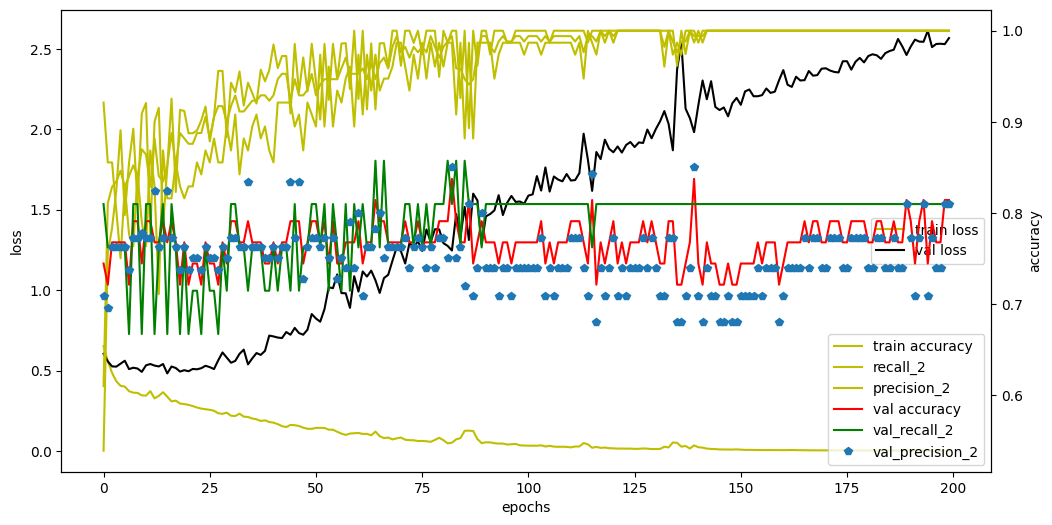

In [170]:
fig, loss_ax = plt.subplots(figsize=(12,6))
loss_ax.plot(hist.history['loss'], 'y', label='train loss')
loss_ax.plot(hist.history['val_loss'], 'k', label='val loss')


acc_ax = loss_ax.twinx()
acc_ax.plot(hist.history['accuracy'], 'y', label='train accuracy')
acc_ax.plot(hist.history['recall_2'], 'y', label='recall_2')
acc_ax.plot(hist.history['precision_2'], 'y', label='precision_2')

acc_ax.plot(hist.history['val_accuracy'], 'r', label='val accuracy')
acc_ax.plot(hist.history['val_recall_2'], 'g', label='val_recall_2')
acc_ax.plot(hist.history['val_precision_2'], 'p', label='val_precision_2')

loss_ax.set_xlabel('epochs')
loss_ax.set_ylabel('loss')
acc_ax.set_ylabel('accuracy')

loss_ax.legend(loc='center right')
acc_ax.legend()
plt.show()

## 3. 모델 평가(그래프, 평가, 교차표)

In [173]:
score = model.evaluate(X_test, y_test, verbose=0)
print('model loss :',score[0])
print('model accuracy :',score[1])
print('model recall :',score[2])
print('model precision :',score[3])

model loss : 2.1844663619995117
model accuracy : 0.8021978139877319
model recall : 0.8333333134651184
model precision : 0.760869562625885


In [176]:
# 교차표
y_test.reshape(-1) # 실제값(1차원으로)

array([1, 1, 0, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 1, 1, 1, 0, 0, 0,
       0, 0, 0, 1, 1, 0, 1, 1, 0, 0, 1, 1, 0, 0, 0, 0, 1, 1, 1, 1, 0, 0,
       1, 0, 1, 1, 1, 0, 1, 0, 0, 0, 1, 0, 0, 0, 1, 1, 1, 1, 1, 0, 0, 0,
       1, 0, 1, 1, 0, 1, 0, 1, 0, 0, 1, 0, 1, 1, 0, 1, 1, 0, 0, 1, 1, 0,
       1, 0, 0], dtype=int64)

In [178]:
y_hat = (model.predict(X_test)>0.5).astype(int).reshape(-1)
y_hat

3/3 [==============================] - 0s 2ms/step


array([1, 1, 0, 1, 1, 0, 1, 0, 0, 1, 0, 0, 0, 0, 1, 0, 0, 1, 1, 0, 0, 0,
       1, 0, 1, 1, 1, 0, 1, 1, 0, 0, 1, 1, 1, 0, 0, 0, 0, 1, 1, 1, 0, 0,
       1, 0, 1, 0, 1, 1, 1, 0, 0, 1, 0, 1, 0, 0, 0, 1, 1, 1, 1, 0, 1, 0,
       1, 0, 1, 1, 0, 1, 1, 0, 1, 0, 0, 0, 1, 1, 0, 1, 1, 0, 0, 1, 1, 0,
       1, 0, 0])

In [179]:
pd.crosstab(y_test.reshape(-1), y_hat, rownames=['실제값'], colnames=['예측값'])

예측값,0,1
실제값,,
0,38,11
1,7,35


## 4. 모델 사용(저장, 예측)

In [180]:
# model.save('model/07heart.h5')
save_model(model, 'model/07heart.h5')

## 5. 모델 가져오기

In [181]:
model2 = load_model('model/07heart.h5')

# 분류분석
```
1. 데이터 셋 생성 & 전처리
      엑셀 -> 데이터프레임 -> ? 처리(df.replace('?',np.nan) -> 결측치 처리
      -> X, y 분리 -> X변수 스케일 조정 -> train_test_split함수로 학습셋과 테스트셋 분리
      -> y 변수들의 원핫인코딩
2. 모델 생성(입력13, 출력2) & 학습과정 설정 & 학습
3. 모델 평가(그래프, 평가, 교차표)
4. 모델 사용(저장, 예측)
```

## 1. 데이터 셋 생성 & 전처리
      엑셀 -> 데이터프레임 -> ? 처리(df.replace('?',np.nan) -> 결측치 처리
      -> X, y 분리 -> X변수 스케일 조정 -> train_test_split함수로 학습셋과 테스트셋 분리
      -> y 변수들의 원핫인코딩

In [51]:
df = pd.read_excel('data/heart-disease.xlsx', 
                    engine='openpyxl', 
                    na_values=['?'], 
                    header=None, 
                    skiprows=1)

df.head()

,0,1,2,3,4,5,6,7,8,9,10,11,12,13
0,63,1,1,145,233.0,1,2,150,0,2.3,3,0.0,6.0,0
1,67,1,4,160,286.0,0,0,108,1,1.5,2,3.0,3.0,1
2,67,1,4,120,NaN,0,2,129,1,2.6,2,2.0,7.0,1
3,37,1,3,130,250.0,0,0,187,0,3.5,3,0.0,3.0,0
4,41,0,2,130,204.0,0,2,172,0,1.4,1,0.0,3.0,0


In [182]:
Y_train = to_categorical(y_train)
Y_test = to_categorical(y_test)
Y_train.shape, Y_test.shape

((212, 2), (91, 2))

## 2. 모델 생성(입력13, 출력2) & 학습과정 설정 & 학습

In [183]:
from tensorflow.keras.layers import Dropout
model = Sequential()
model.add(Input(shape=(13,)))
model.add(Dense(32, activation='relu'))
model.add(Dense(8, activation='relu'))
model.add(Dense(2, activation='softmax'))
model.summary()

Model: "sequential_10"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 dense_36 (Dense)            (None, 32)                448       
                                                                 
 dense_37 (Dense)            (None, 8)                 264       
                                                                 
 dense_38 (Dense)            (None, 2)                 18        
                                                                 
Total params: 730
Trainable params: 730
Non-trainable params: 0
_________________________________________________________________


#### compile

In [184]:
from tensorflow.keras import metrics
from tensorflow.keras.optimizers import Adam
model.compile(loss='categorical_crossentropy',
              optimizer=Adam(learning_rate=0.01),
              metrics=['accuracy',  # 정확도
                       metrics.Recall(), #재현율(실제값중심)
                       metrics.Precision()]) # 정밀도(예측값중심)

In [185]:
hist = model.fit(X_train, Y_train, # 훈련데이터
                epochs=200,
#                 batch_size=,
                validation_split=0.2, # 검증데이터를 훈련데이터의 20%로 사용
                verbose=1)

Epoch 1/200
6/6 [==============================] - 1s 52ms/step - loss: 0.6886 - accuracy: 0.5503 - recall_3: 0.5503 - precision_3: 0.5503 - val_loss: 0.6633 - val_accuracy: 0.5116 - val_recall_3: 0.5116 - val_precision_3: 0.5116
Epoch 2/200
6/6 [==============================] - 0s 9ms/step - loss: 0.6248 - accuracy: 0.5503 - recall_3: 0.5503 - precision_3: 0.5503 - val_loss: 0.6347 - val_accuracy: 0.5116 - val_recall_3: 0.5116 - val_precision_3: 0.5116
Epoch 3/200
6/6 [==============================] - 0s 9ms/step - loss: 0.5836 - accuracy: 0.5917 - recall_3: 0.5917 - precision_3: 0.5917 - val_loss: 0.5978 - val_accuracy: 0.7209 - val_recall_3: 0.7209 - val_precision_3: 0.7209
Epoch 4/200
6/6 [==============================] - 0s 8ms/step - loss: 0.5332 - accuracy: 0.7811 - recall_3: 0.7811 - precision_3: 0.7811 - val_loss: 0.5628 - val_accuracy: 0.8140 - val_recall_3: 0.8140 - val_precision_3: 0.8140
Epoch 5/200
6/6 [==============================] - 0s 9ms/step - loss: 0.4743 - acc

Epoch 37/200
6/6 [==============================] - 0s 8ms/step - loss: 0.1976 - accuracy: 0.9231 - recall_3: 0.9231 - precision_3: 0.9231 - val_loss: 0.6068 - val_accuracy: 0.8372 - val_recall_3: 0.8372 - val_precision_3: 0.8372
Epoch 38/200
6/6 [==============================] - 0s 8ms/step - loss: 0.1856 - accuracy: 0.9290 - recall_3: 0.9290 - precision_3: 0.9290 - val_loss: 0.6620 - val_accuracy: 0.8372 - val_recall_3: 0.8372 - val_precision_3: 0.8372
Epoch 39/200
6/6 [==============================] - 0s 10ms/step - loss: 0.1795 - accuracy: 0.9290 - recall_3: 0.9290 - precision_3: 0.9290 - val_loss: 0.6421 - val_accuracy: 0.8372 - val_recall_3: 0.8372 - val_precision_3: 0.8372
Epoch 40/200
6/6 [==============================] - 0s 9ms/step - loss: 0.2462 - accuracy: 0.8994 - recall_3: 0.8994 - precision_3: 0.8994 - val_loss: 0.6397 - val_accuracy: 0.8372 - val_recall_3: 0.8372 - val_precision_3: 0.8372
Epoch 41/200
6/6 [==============================] - 0s 10ms/step - loss: 0.2003

Epoch 73/200
6/6 [==============================] - 0s 8ms/step - loss: 0.0553 - accuracy: 0.9941 - recall_3: 0.9941 - precision_3: 0.9941 - val_loss: 0.9451 - val_accuracy: 0.8837 - val_recall_3: 0.8837 - val_precision_3: 0.8837
Epoch 74/200
6/6 [==============================] - 0s 8ms/step - loss: 0.0565 - accuracy: 0.9941 - recall_3: 0.9941 - precision_3: 0.9941 - val_loss: 0.9245 - val_accuracy: 0.8837 - val_recall_3: 0.8837 - val_precision_3: 0.8837
Epoch 75/200
6/6 [==============================] - 0s 8ms/step - loss: 0.0557 - accuracy: 0.9941 - recall_3: 0.9941 - precision_3: 0.9941 - val_loss: 0.9510 - val_accuracy: 0.8837 - val_recall_3: 0.8837 - val_precision_3: 0.8837
Epoch 76/200
6/6 [==============================] - 0s 8ms/step - loss: 0.0564 - accuracy: 0.9882 - recall_3: 0.9882 - precision_3: 0.9882 - val_loss: 1.0222 - val_accuracy: 0.8605 - val_recall_3: 0.8605 - val_precision_3: 0.8605
Epoch 77/200
6/6 [==============================] - 0s 9ms/step - loss: 0.0538 -

6/6 [==============================] - 0s 8ms/step - loss: 0.0088 - accuracy: 1.0000 - recall_3: 1.0000 - precision_3: 1.0000 - val_loss: 1.5078 - val_accuracy: 0.8605 - val_recall_3: 0.8605 - val_precision_3: 0.8605
Epoch 144/200
6/6 [==============================] - 0s 8ms/step - loss: 0.0085 - accuracy: 1.0000 - recall_3: 1.0000 - precision_3: 1.0000 - val_loss: 1.5271 - val_accuracy: 0.8605 - val_recall_3: 0.8605 - val_precision_3: 0.8605
Epoch 145/200
6/6 [==============================] - 0s 8ms/step - loss: 0.0086 - accuracy: 1.0000 - recall_3: 1.0000 - precision_3: 1.0000 - val_loss: 1.5756 - val_accuracy: 0.8605 - val_recall_3: 0.8605 - val_precision_3: 0.8605
Epoch 146/200
6/6 [==============================] - 0s 8ms/step - loss: 0.0079 - accuracy: 1.0000 - recall_3: 1.0000 - precision_3: 1.0000 - val_loss: 1.5640 - val_accuracy: 0.8605 - val_recall_3: 0.8605 - val_precision_3: 0.8605
Epoch 147/200
6/6 [==============================] - 0s 8ms/step - loss: 0.0078 - accuracy

## 3. 모델 평가(그래프, 평가, 교차표)

In [186]:
hist.history.keys()

dict_keys(['loss', 'accuracy', 'recall_3', 'precision_3', 'val_loss', 'val_accuracy', 'val_recall_3', 'val_precision_3'])

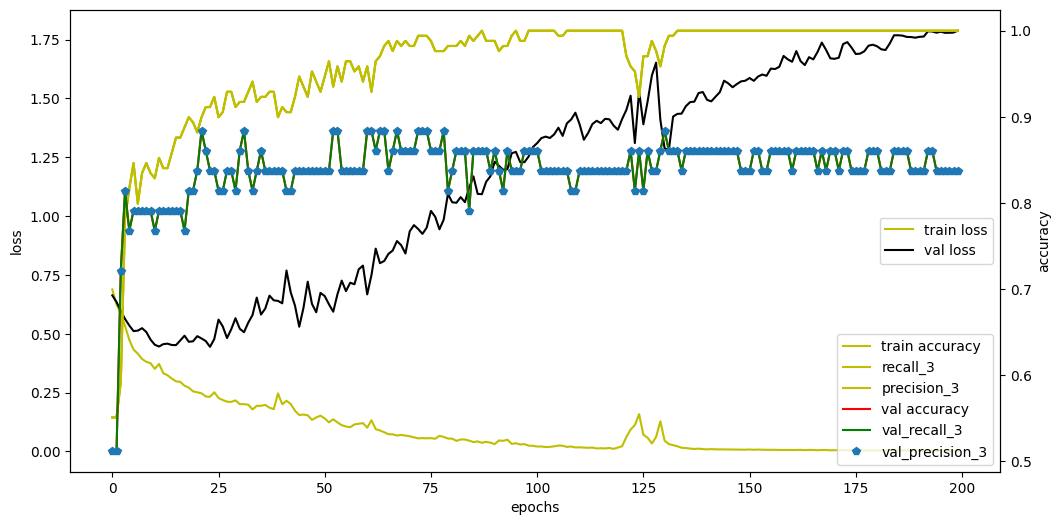

In [188]:
fig, loss_ax = plt.subplots(figsize=(12,6))
loss_ax.plot(hist.history['loss'], 'y', label='train loss')
loss_ax.plot(hist.history['val_loss'], 'k', label='val loss')


acc_ax = loss_ax.twinx()
acc_ax.plot(hist.history['accuracy'], 'y', label='train accuracy')
acc_ax.plot(hist.history['recall_3'], 'y', label='recall_3')
acc_ax.plot(hist.history['precision_3'], 'y', label='precision_3')

acc_ax.plot(hist.history['val_accuracy'], 'r', label='val accuracy')
acc_ax.plot(hist.history['val_recall_3'], 'g', label='val_recall_3')
acc_ax.plot(hist.history['val_precision_3'], 'p', label='val_precision_3')

loss_ax.set_xlabel('epochs')
loss_ax.set_ylabel('loss')
acc_ax.set_ylabel('accuracy')

loss_ax.legend(loc='center right')
acc_ax.legend()
plt.show()

In [189]:
score = model.evaluate(X_test, Y_test, verbose=0)
print('model loss :',score[0])
print('model accuracy :',score[1])
print('model recall :',score[2])
print('model precision :',score[3])

model loss : 2.153308391571045
model accuracy : 0.7582417726516724
model recall : 0.7582417726516724
model precision : 0.7582417726516724


In [ ]:
# 교차표
y_test.reshape(-1) # 실제값(1차원으로)

In [190]:
y_hat = model.predict(X_test).argmax(axis=1)
y_hat

3/3 [==============================] - 0s 2ms/step


array([1, 1, 0, 1, 1, 0, 1, 0, 0, 1, 0, 0, 0, 0, 1, 0, 0, 1, 1, 0, 0, 1,
       1, 1, 1, 1, 1, 0, 1, 1, 0, 0, 1, 0, 1, 0, 0, 1, 1, 1, 1, 1, 0, 0,
       1, 0, 1, 0, 1, 1, 1, 0, 0, 1, 0, 1, 0, 0, 0, 1, 1, 1, 1, 0, 0, 0,
       1, 0, 1, 1, 0, 1, 1, 0, 1, 1, 0, 0, 1, 1, 0, 1, 1, 0, 0, 0, 1, 0,
       1, 0, 0], dtype=int64)

In [193]:
pd.crosstab(y_test.reshape(-1), y_hat, rownames=['실제값'], colnames=['예측값'])

예측값,0,1
실제값,,
0,35,14
1,8,34
